In [6]:
import os
import sys
p = os.path.abspath('../..')
if p not in sys.path:
    sys.path.append(p)
import numpy as np
import matplotlib.pyplot as plt
import zarr
import waveorder as wo
import tifffile as tiff
from recOrder.recOrder.postproc.plot_overlays import overlay_retardance_orientation, create_legend

In [7]:
new = tiff.TiffFile('/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_03_05_40x_04NA_A549 phalloidin/RSV48/_1/_1_MMStack_7.ome.tif')
old = tiff.TiffFile('/gpfs/CompMicro/rawdata/hummingbird/Janie/2021_03_05_40x_04NA_A549 phalloidin/RSV48/_1/_1_MMStack.ome.tif')



In [2]:
mock_24hr_array = zarr.open('/gpfs/CompMicro/projects/A549/210203_40x_04_NA_A549/24hr_Mock.zarr', mode='r')
print(mock_24hr_array.tree())

/
 ├── C1
 │   ├── BF (5, 65, 2048, 2448) float32
 │   ├── Fluor (5, 2, 65, 2048, 2448) uint16
 │   ├── Orientation (5, 65, 2048, 2448) float32
 │   ├── Phase3D (5, 65, 2048, 2448) float32
 │   └── Retardance (5, 65, 2048, 2448) float32
 └── C2
     ├── BF (5, 65, 2048, 2448) float32
     ├── Fluor (5, 2, 65, 2048, 2448) uint16
     ├── Orientation (5, 65, 2048, 2448) float32
     ├── Phase3D (5, 65, 2048, 2448) float32
     └── Retardance (5, 65, 2048, 2448) float32


In [ ]:
mock_24hr_array = zarr.open('/gpfs/CompMicro/projects/A549/210203_40x_04_NA_A549/24hr_Mock.zarr', mode='r')

In [3]:
pos = 0
z = 31

ret = mock_24hr_array['C1']['Retardance'][pos][z]
ori = mock_24hr_array['C1']['Orientation'][pos][z]*180/np.pi

In [4]:
np.max(ret)

54.495914

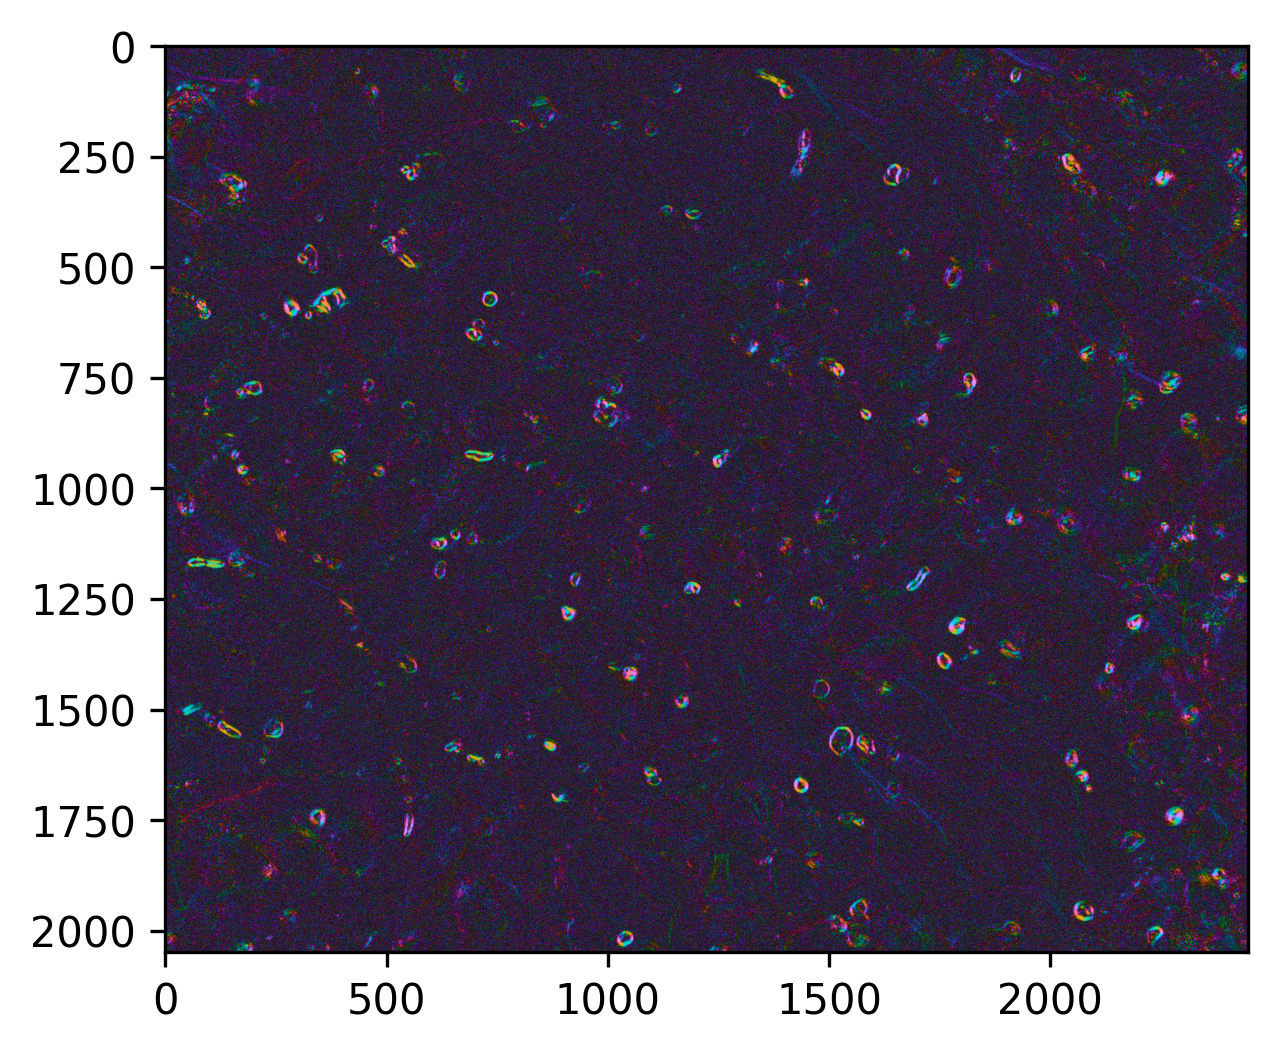

In [8]:
overlay_img = overlay_retardance_orientation(ret, ori, ret_scale=(0, 10), method='JCH', 
                                             ret_noise_level=2, ori_scale = (0, 180))

plt.figure(dpi=300)
plt.imshow(overlay_img)
plt.show()

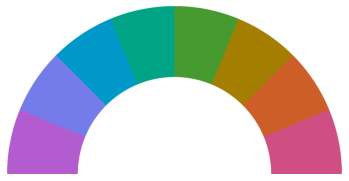

In [7]:
legend = create_legend()

In [17]:
from colorspacious import cspace_convert


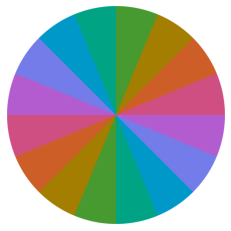

In [21]:
[xLeg, yLeg] = np.meshgrid(np.arange(-1, 1+0.001, 0.001), np.arange(-1, 1+0.001, 0.001))
rhoLeg = np.sqrt(xLeg**2 + yLeg**2)
thetaLeg = np.arctan2(-yLeg, xLeg)

# print(thetaLeg)
# thetaLeg 
thetaLeg %= np.pi
# thetaLeg -= np.pi/2
thetaLeg /= np.pi

alpha = np.ones_like(rhoLeg)
alpha[rhoLeg>=1] = 0
# alpha[rhoLeg<np.sqrt(1/3)] = 0

levels = 8

thetaLeg_ = np.round(thetaLeg*levels+0.5)/levels - 1/levels

J = np.ones_like(rhoLeg) * 45
C = np.ones_like(rhoLeg) * 60
h = thetaLeg_*360

JCh = np.stack((J, C, h), axis=2)
JCh_rgb = cspace_convert(JCh, "JCh", "sRGB1")

JCh_rgb[JCh_rgb<0]=0
JCh_rgb[JCh_rgb>1]=1

legend = np.dstack((JCh_rgb, alpha))

plt.imshow(legend)
plt.axis('off')
plt.imsave('/home/camfoltz2/Desktop/JCh_colorLegend_fullCircle.png', legend)
plt.show()

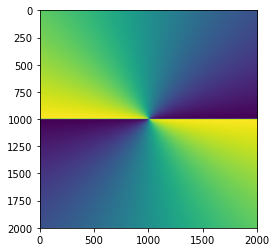

In [16]:
plt.imshow(thetaLeg)

In [ ]:
def create_legend(method='JCH',levels=8):
    
    [xLeg, yLeg] = np.meshgrid(np.arange(-1, 1+0.001, 0.001), np.arange(-1, 0.001, 0.001))
    rhoLeg = np.sqrt(xLeg**2 + yLeg**2)
    thetaLeg = np.arctan2(-yLeg, xLeg)

    # print(thetaLeg)
    # thetaLeg 
    thetaLeg %= np.pi
    # thetaLeg -= np.pi/2
    thetaLeg /= np.pi

    alpha = np.ones_like(rhoLeg)
    alpha[rhoLeg>=1] = 0
    alpha[rhoLeg<np.sqrt(1/3)] = 0

    levels = 8

    thetaLeg_ = np.round(thetaLeg*levels+0.5)/levels - 1/levels

    J = np.ones_like(rhoLeg) * 45
    C = np.ones_like(rhoLeg) * 60
    h = thetaLeg_*360

    JCh = np.stack((J, C, h), axis=2)
    JCh_rgb = cspace_convert(JCh, "JCh", "sRGB1")

    JCh_rgb[JCh_rgb<0]=0
    JCh_rgb[JCh_rgb>1]=1

    legend = np.dstack((JCh_rgb, alpha))

    plt.imshow(legend)
    plt.show()
    
    return legend